In [1]:
import pandas as pd
import numpy as np
from skmultilearn.model_selection import IterativeStratification

In [2]:
df = pd.read_csv("data/input/all_data.csv")

In [3]:
df.columns

Index(['id', 'comment_text', 'split', 'created_date', 'publication_id',
       'parent_id', 'article_id', 'rating', 'funny', 'wow', 'sad', 'likes',
       'disagree', 'toxicity', 'severe_toxicity', 'obscene', 'sexual_explicit',
       'identity_attack', 'insult', 'threat', 'male', 'female', 'transgender',
       'other_gender', 'heterosexual', 'homosexual_gay_or_lesbian', 'bisexual',
       'other_sexual_orientation', 'christian', 'jewish', 'muslim', 'hindu',
       'buddhist', 'atheist', 'other_religion', 'black', 'white', 'asian',
       'latino', 'other_race_or_ethnicity', 'physical_disability',
       'intellectual_or_learning_disability', 'psychiatric_or_mental_illness',
       'other_disability', 'identity_annotator_count',
       'toxicity_annotator_count'],
      dtype='str')

In [4]:
df.drop(columns=['id', 'split', 'created_date', 'publication_id',
       'parent_id', 'article_id', 'rating', 'funny', 'wow', 'sad', 'likes',
       'disagree', 'severe_toxicity',
       'male', 'female', 'transgender',
       'other_gender', 'heterosexual', 'homosexual_gay_or_lesbian', 'bisexual',
       'other_sexual_orientation', 'christian', 'jewish', 'muslim', 'hindu',
       'buddhist', 'atheist', 'other_religion', 'black', 'white', 'asian',
       'latino', 'other_race_or_ethnicity', 'physical_disability',
       'intellectual_or_learning_disability', 'psychiatric_or_mental_illness',
       'other_disability', 'identity_annotator_count',
       'toxicity_annotator_count'], inplace=True)


df.head()

,comment_text,toxicity,obscene,sexual_explicit,identity_attack,insult,threat
0,He got his money... now he lies in wait till a...,0.373134,0.089552,0.014925,0.000000,0.343284,0.014925
1,Mad dog will surely put the liberals in mental...,0.605263,0.065789,0.013158,0.092105,0.565789,0.065789
2,And Trump continues his lifelong cowardice by ...,0.666667,0.031746,0.000000,0.047619,0.666667,0.000000
3,"""while arresting a man for resisting arrest"".\...",0.815789,0.552632,0.592105,0.000000,0.684211,0.105263
4,Tucker and Paul are both total bad ass mofo's.,0.550000,0.337500,0.275000,0.037500,0.487500,0.000000


In [5]:
df.columns

Index(['comment_text', 'toxicity', 'obscene', 'sexual_explicit',
       'identity_attack', 'insult', 'threat'],
      dtype='str')

In [6]:
df[['toxicity', 'obscene', 'sexual_explicit', 'identity_attack', 'insult', 'threat']] = df[['toxicity', 'obscene', 'sexual_explicit', 'identity_attack', 'insult', 'threat']].map(lambda x: 0 if x<0.5 else 1)

In [7]:
# Assuming df is the final dataframe from your Untitled-1.py script
# Target columns we need to stratify against
label_cols = ['toxicity', 'obscene', 'sexual_explicit', 'identity_attack', 'insult', 'threat']

X = df['comment_text'].values
y = df[label_cols].values

In [8]:
# Note: IterativeStratification can take a few minutes on 1.8M rows. 
stratifier = IterativeStratification(n_splits=2, order=1, sample_distribution_per_fold=[0.8, 0.2])

# skmultilearn requires data in a specific format for splitting
for temp_idx, test_idx in stratifier.split(X, y):
    pass  # The loop runs once to yield the indices

X_temp, y_temp = X[temp_idx], y[temp_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"Temp Set Size: {len(X_temp)}")
print(f"Test Set Size: {len(X_test)}")

Temp Set Size: 1599612
Test Set Size: 399904


In [9]:
# We split the 80% Temp set again. 
# 20% of 80% is 16%, leaving 64% for final training. 
# You can adjust the sample_distribution if you specifically want 80/20 of the ENTIRE dataset.
# Here we do an 80/20 split of the temp dataset.
stratifier_val = IterativeStratification(n_splits=2, order=1, sample_distribution_per_fold=[0.8, 0.2])

for train_idx, val_idx in stratifier_val.split(X_temp, y_temp):
    pass

X_train, y_train = X_temp[train_idx], y_temp[train_idx]
X_val, y_val = X_temp[val_idx], y_temp[val_idx]

print(f"Final Train Size: {len(X_train)}")
print(f"Final Validation Size: {len(X_val)}")

Final Train Size: 1279689
Final Validation Size: 319923


In [10]:
def save_split(X_data, y_data, filename):
    dataset = pd.DataFrame({'comment_text': X_data})
    dataset[label_cols] = y_data
    dataset.to_csv(filename, index=False)
    print(f"Saved {filename}")

save_split(X_train, y_train, "data/input/train_split.csv")
save_split(X_val, y_val, "data/input/val_split.csv")
save_split(X_test, y_test, "data/input/test_split.csv")

Saved data/input/train_split.csv
Saved data/input/val_split.csv
Saved data/input/test_split.csv


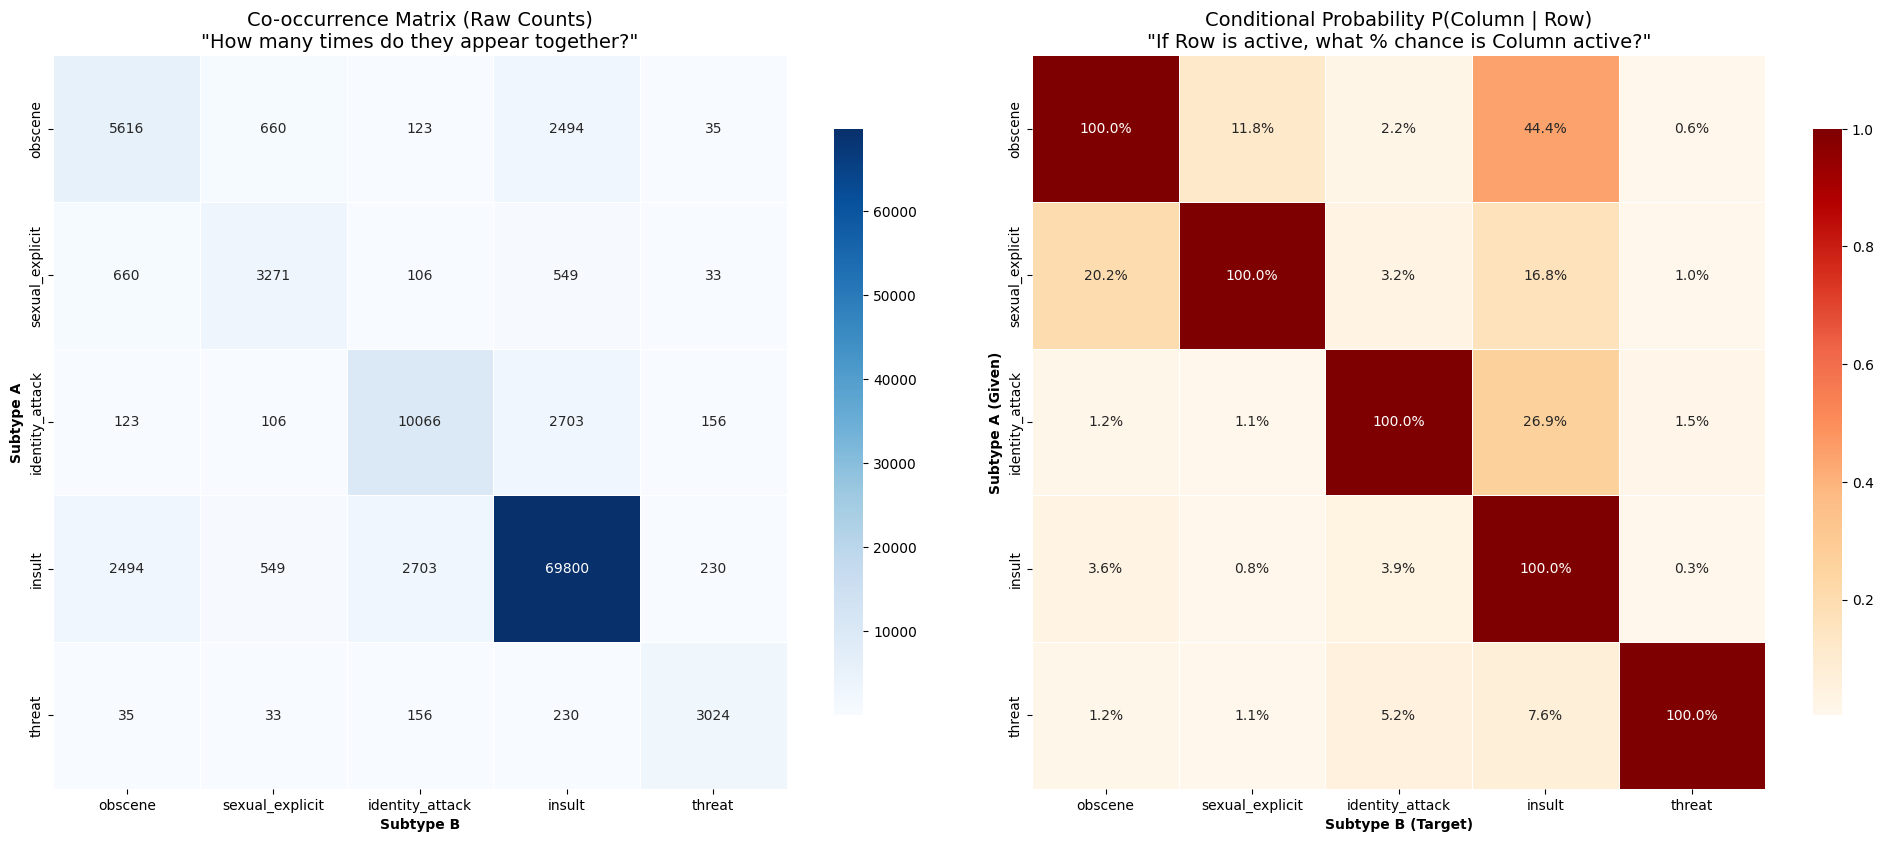

Top 3 Strongest Subtype Relationships (Conditional):
 - If 'obscene', there is a 44.4% chance of 'insult'
 - If 'identity_attack', there is a 26.9% chance of 'insult'
 - If 'sexual_explicit', there is a 20.2% chance of 'obscene'


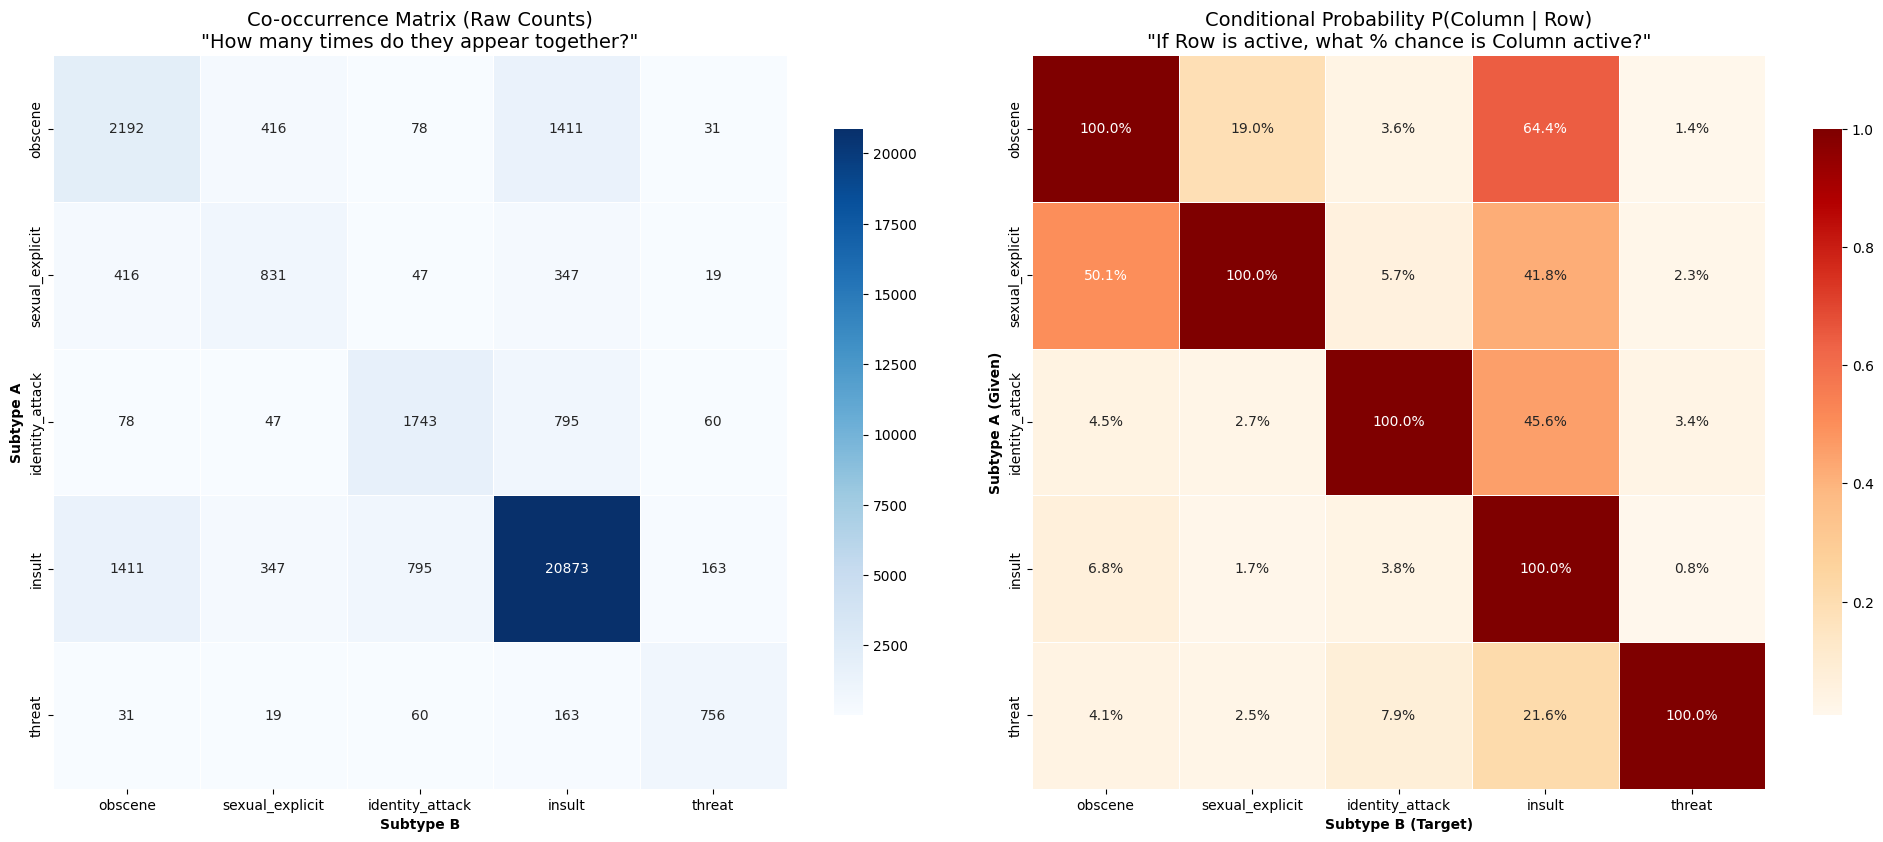

Top 3 Strongest Subtype Relationships (Conditional):
 - If 'obscene', there is a 64.4% chance of 'insult'
 - If 'sexual_explicit', there is a 50.1% chance of 'obscene'
 - If 'identity_attack', there is a 45.6% chance of 'insult'


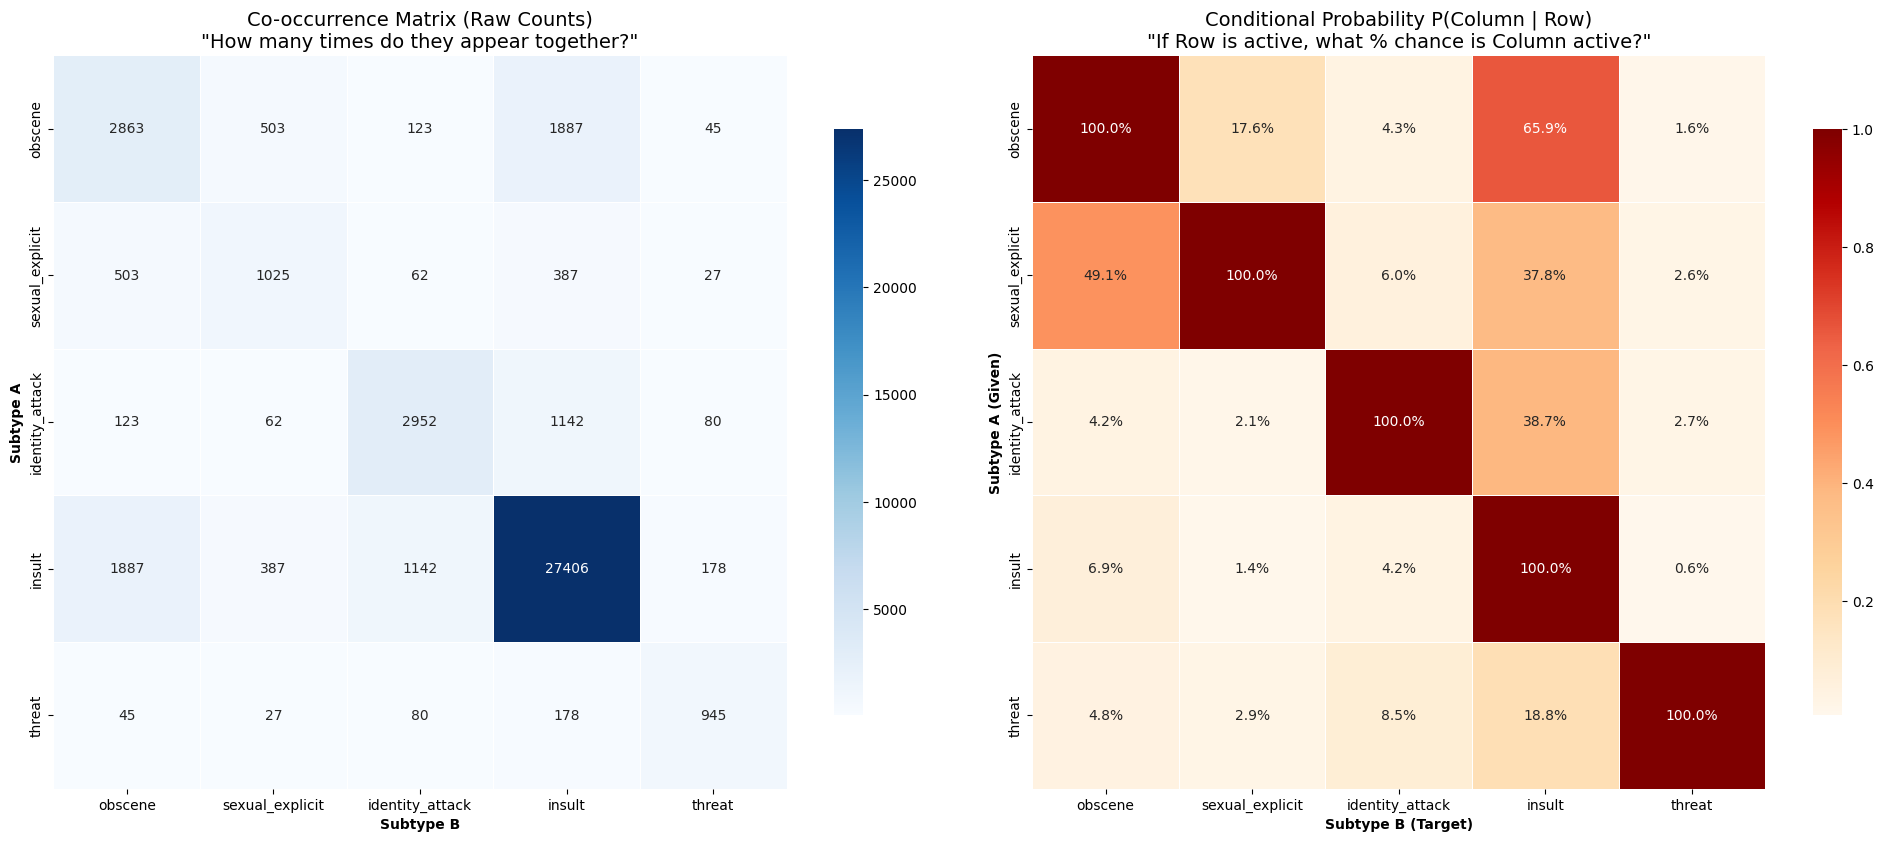

Top 3 Strongest Subtype Relationships (Conditional):
 - If 'obscene', there is a 65.9% chance of 'insult'
 - If 'sexual_explicit', there is a 49.1% chance of 'obscene'
 - If 'identity_attack', there is a 38.7% chance of 'insult'


In [11]:
# %%
# ─────────────────────────────────────────────
# ENHANCED CO-OCCURRENCE ANALYSIS
# ─────────────────────────────────────────────
import numpy as np
SUBTYPE_COLS = ['obscene', 'sexual_explicit', 'identity_attack', 'insult', 'threat']
import seaborn as sns
import matplotlib.pyplot as plt 
for _ in ["data/input/train_split.csv","data/input/val_split.csv","data/input/test_split.csv"]:
    df = pd.read_csv(_)
    # Create binary mask for subtypes >= 0.5
    binary_subtypes = (df[SUBTYPE_COLS] >= 0.5).astype(int)

    # 1. Absolute Co-occurrence (Raw Counts)
    co_occurrence_counts = binary_subtypes.T.dot(binary_subtypes)

    # 2. Normalized Co-occurrence (Conditional Probability)
    # Formula: P(Column | Row) = Count(Row & Col) / Count(Row)
    # This divides each row by the total occurrences of that specific subtype
    diagonal_counts = np.diag(co_occurrence_counts)
    co_occurrence_prob = co_occurrence_counts.divide(diagonal_counts, axis=0)

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Plot 1: Raw Counts
    sns.heatmap(co_occurrence_counts, annot=True, cmap='Blues', fmt="d", 
                square=True, ax=axes[0], cbar_kws={"shrink": 0.8}, linewidths=0.5)
    axes[0].set_title('Co-occurrence Matrix (Raw Counts)\n"How many times do they appear together?"', fontsize=14)
    axes[0].set_xlabel('Subtype B', fontweight='bold')
    axes[0].set_ylabel('Subtype A', fontweight='bold')

    # Plot 2: Conditional Probabilities
    sns.heatmap(co_occurrence_prob, annot=True, cmap='OrRd', fmt=".1%", 
                square=True, ax=axes[1], cbar_kws={"shrink": 0.8}, linewidths=0.5)
    axes[1].set_title('Conditional Probability P(Column | Row)\n"If Row is active, what % chance is Column active?"', fontsize=14)
    axes[1].set_xlabel('Subtype B (Target)', fontweight='bold')
    axes[1].set_ylabel('Subtype A (Given)', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Optional: Print the strongest relationships
    print("Top 3 Strongest Subtype Relationships (Conditional):")
    # Flatten the matrix, remove self-correlations (100%), and sort
    stacked_probs = co_occurrence_prob.stack().reset_index()
    stacked_probs.columns = ['Given_Subtype', 'Target_Subtype', 'Probability']
    stacked_probs = stacked_probs[stacked_probs['Given_Subtype'] != stacked_probs['Target_Subtype']]
    top_relations = stacked_probs.sort_values(by='Probability', ascending=False).head(3)

    for idx, row in top_relations.iterrows():
        print(f" - If '{row['Given_Subtype']}', there is a {row['Probability']*100:.1f}% chance of '{row['Target_Subtype']}'")